# EDA y limpieza del dataset Fintech

Este notebook sigue el orden metodológico:

**datos RAW → exploración inicial → EDA completo → conclusiones para la limpieza → limpieza → validación → exportación**

Durante todo el EDA se utilizan los nombres **originales** del dataset (`job`, `education`, `default`, `month`, `duration`, `y`, etc.).  
La función `limpieza_fintech()` se ejecuta **únicamente después de terminar el EDA**.


## Paso 1. Importación de librerías, funciones y definición de rutas


In [39]:
# Importamos sys para añadir la carpeta de scripts al path de Python.
import sys
# Importamos Path para gestionar las rutas del proyecto.
from pathlib import Path
# Importamos pandas para manipular y analizar los datos.
import pandas as pd
# Importamos numpy para realizar operaciones numéricas.
import numpy as np
# Importamos seaborn para crear gráficos estadísticos.
import seaborn as sns
# Importamos matplotlib para crear y personalizar visualizaciones.
import matplotlib.pyplot as plt
# Importamos scipy.stats para realizar contrastes estadísticos.
import scipy.stats as stats

# Definimos la ruta principal del proyecto.
PROJECT_DIR = Path("/home/diego/Escritorio/Fintech_TFM")
# Definimos la carpeta general de datos.
DATA_DIR = PROJECT_DIR / "00_data"
# Definimos la carpeta que contiene el dataset original.
RAW_DIR = DATA_DIR / "00_raw"
# Definimos la carpeta que contiene funciones_fintech.py.
SCRIPTS_DIR = PROJECT_DIR / "02_scripts"
# Definimos la ruta exacta del dataset RAW.
INPUT_FILE = RAW_DIR / "fintech_raw_data.csv"
# Definimos la ruta del dataset limpio que se generará al final.
OUTPUT_FILE = DATA_DIR /"01_processed/" /"df_fintech_final.csv"

# Comprobamos que el dataset RAW existe.
assert INPUT_FILE.exists(), f"No se encuentra el dataset: {INPUT_FILE}"
# Comprobamos que el archivo de funciones existe.
assert (SCRIPTS_DIR / "funciones_fintech.py").exists(), f"No se encuentra funciones_fintech.py en {SCRIPTS_DIR}"

# Añadimos 02_scripts al path si todavía no está incluido.
if str(SCRIPTS_DIR) not in sys.path:
    # Insertamos la carpeta de scripts al principio del path.
    sys.path.insert(0, str(SCRIPTS_DIR))

# Importamos la función de exploración inicial del proyecto.
from funciones_fintech import exploracion_inicial
# Importamos la función de limpieza del proyecto.
from funciones_fintech import limpieza_fintech

# Configuramos pandas para mostrar todas las columnas.
pd.set_option("display.max_columns", None)
# Aplicamos un estilo limpio a las visualizaciones.
sns.set_theme(style="whitegrid")
# Definimos una paleta común para mantener coherencia visual.
PALETTE = ["#6A0DAD", "#9A7FBF", "#C0C0C0", "#E6E6FA"]

# Mostramos las rutas principales para comprobar la configuración.
print(f"Entrada RAW: {INPUT_FILE}")
# Mostramos la ubicación del archivo de funciones.
print(f"Funciones: {SCRIPTS_DIR / 'funciones_fintech.py'}")
# Mostramos la ubicación prevista del resultado final.
print(f"Salida limpia: {OUTPUT_FILE}")


Entrada RAW: /home/diego/Escritorio/Fintech_TFM/00_data/00_raw/fintech_raw_data.csv
Funciones: /home/diego/Escritorio/Fintech_TFM/02_scripts/funciones_fintech.py
Salida limpia: /home/diego/Escritorio/Fintech_TFM/00_data/01_processed/df_fintech_final.csv


## Paso 2. Carga del dataset RAW

El CSV original está separado por `;`. Por ello se utiliza `pd.read_csv(..., sep=";")`. La función `leer_archivo()` actual no especifica este separador y, aplicada directamente a este fichero, leería toda la fila como una sola columna.


In [40]:
# Leemos el fichero RAW indicando explícitamente el separador correcto.
df_fintech = pd.read_csv(INPUT_FILE, sep=";")
# Mostramos las primeras filas para comprobar que la lectura es correcta.
display(df_fintech.head())
# Mostramos las dimensiones iniciales del dataset.
print(f"Dimensiones iniciales: {df_fintech.shape[0]:,} filas x {df_fintech.shape[1]} columnas")
# Comprobamos que la variable objetivo original se llama y.
assert "y" in df_fintech.columns, "No se encuentra la variable objetivo 'y'."
# Comprobamos que se han leído varias columnas y no una única columna por un separador incorrecto.
assert df_fintech.shape[1] > 1, "El CSV parece haberse leído con un separador incorrecto."


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Dimensiones iniciales: 41,188 filas x 21 columnas


## Paso 3. Exploración inicial mediante `exploracion_inicial()`


¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 41,188 filas y 21 columnas.
##########################################################################################
¿Cuáles son las primeras cinco filas del conjunto de datos?


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


----------------------------------------------------------------------------------------------------
¿Cuáles son las últimas cinco filas del conjunto de datos?


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,239,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no


----------------------------------------------------------------------------------------------------
¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


...

----------------------------------------------------------------------------------------------------
¿Cuántos valores nulos hay en cada columna del DataFrame?


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

----------------------------------------------------------------------------------------------------
¿Cuál es el porcentaje de valores nulos por columna, ordenado de mayor a menor?


,Col,pct
0,age,0.0
1,job,0.0
2,marital,0.0
3,education,0.0
4,default,0.0
5,housing,0.0
6,loan,0.0
7,contact,0.0
8,month,0.0
9,day_of_week,0.0


----------------------------------------------------------------------------------------------------
## Valores nulos: Visualización


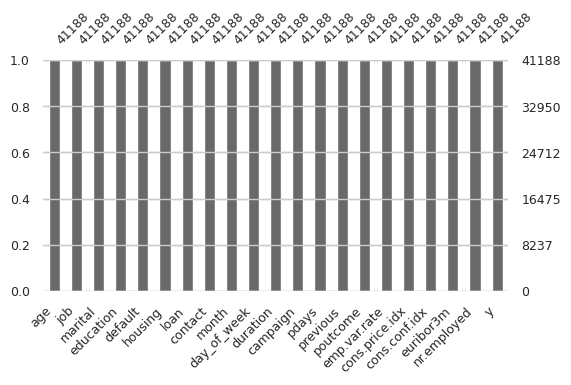

----------------------------------------------------------------------------------------------------
## Visualización de patrones en valores nulos


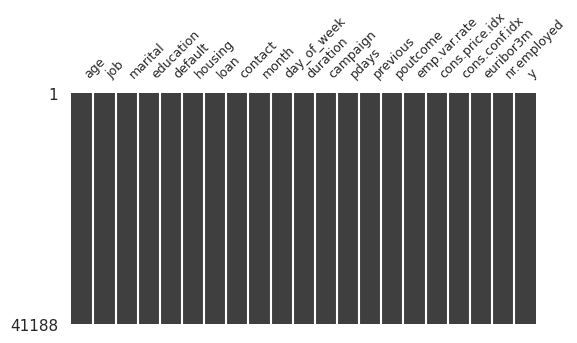

----------------------------------------------------------------------------------------------------
##Número de filas duplicadas (considerando todas las columnas)
	Hay 12 filas duplicadas.


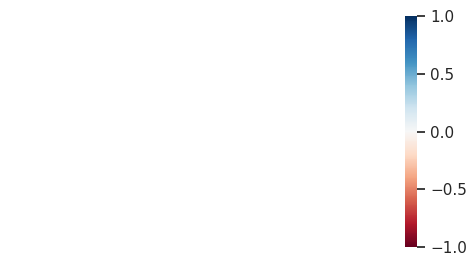

----------------------------------------------------------------------------------------------------
##########################################################################################


In [41]:
# Ejecutamos la función propia para realizar una exploración completa del dataset RAW.
exploracion_inicial(df_fintech)


## Paso 4. Preparación de variables auxiliares exclusivamente para el EDA


In [42]:
# Creamos una copia de trabajo para conservar intacta una referencia del RAW cargado.
df_eda = df_fintech.copy()

# Creamos una versión numérica temporal de la variable objetivo.
df_eda["y_num"] = df_eda["y"].map({"yes": 1, "no": 0})

# Creamos grupos de edad únicamente para facilitar el análisis exploratorio.
df_eda["age_group"] = pd.cut(
    # Utilizamos la edad original.
    df_eda["age"],
    # Definimos los límites de los intervalos.
    bins=[16, 25, 35, 50, 65, 100],
    # Asignamos etiquetas interpretables.
    labels=["18-25", "26-35", "36-50", "51-65", "65+"],
    # Incluimos el límite inferior.
    include_lowest=True
)

# Definimos el orden cronológico de los meses presentes en el dataset.
orden_meses = ["mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
# Convertimos month en una categoría ordenada únicamente dentro de la copia de EDA.
df_eda["month"] = pd.Categorical(df_eda["month"], categories=orden_meses, ordered=True)

# Definimos el orden de los días laborables.
orden_dias = ["mon", "tue", "wed", "thu", "fri"]
# Convertimos day_of_week en una categoría ordenada para las visualizaciones.
df_eda["day_of_week"] = pd.Categorical(df_eda["day_of_week"], categories=orden_dias, ordered=True)

# Creamos grupos de duración de llamada para reproducir el análisis del notebook de referencia.
df_eda["duration_group"] = pd.cut(
    # Utilizamos la duración original expresada en segundos.
    df_eda["duration"],
    # Definimos los intervalos de duración.
    bins=[-1, 60, 180, 300, 600, 1200, 10000],
    # Asignamos etiquetas comprensibles.
    labels=["0-1 min", "2-3 min", "4-5 min", "6-10 min", "11-20 min", "21+ min"]
)

# Creamos un indicador temporal para distinguir clientes sin contactos previos.
df_eda["is_new_campaign_client_eda"] = np.where(df_eda["previous"] == 0, "yes", "no")

# Creamos un indicador temporal de alta intensidad de contactos en la campaña actual.
df_eda["high_contact_attempts_eda"] = np.where(df_eda["campaign"] > 3, "yes", "no")

# Creamos grupos temporales para pdays interpretando 999 como ausencia de contacto previo.
df_eda["pdays_group"] = pd.cut(
    # Sustituimos 999 temporalmente por NaN para crear los intervalos del resto de observaciones.
    df_eda["pdays"].replace(999, np.nan),
    # Definimos intervalos de días desde el último contacto.
    bins=[-1, 7, 14, 30, np.inf],
    # Asignamos etiquetas descriptivas.
    labels=["0-7 días", "8-14 días", "15-30 días", "31+ días"]
)

# Añadimos una categoría específica para quienes nunca fueron contactados.
df_eda["pdays_group"] = df_eda["pdays_group"].cat.add_categories(["Sin contacto previo"])
# Asignamos la categoría especial a los registros con pdays igual a 999.
df_eda.loc[df_eda["pdays"] == 999, "pdays_group"] = "Sin contacto previo"

# Creamos un indicador temporal para estudiar los valores unknown de default.
df_eda["default_unknown"] = (df_eda["default"] == "unknown").astype(int)

# Mostramos una muestra de las variables auxiliares.
display(df_eda[["age", "age_group", "y", "y_num", "duration_group", "pdays_group"]].head())


,age,age_group,y,y_num,duration_group,pdays_group
0,56,51-65,no,0,4-5 min,Sin contacto previo
1,57,51-65,no,0,2-3 min,Sin contacto previo
2,37,36-50,no,0,4-5 min,Sin contacto previo
3,40,36-50,no,0,2-3 min,Sin contacto previo
4,56,51-65,no,0,6-10 min,Sin contacto previo


## Paso 5. Análisis de calidad de datos antes de limpiar


In [43]:
# Calculamos el número de duplicados exactos del dataset original.
duplicados_exactos = df_fintech.duplicated().sum()
# Mostramos el resultado.
print(f"Duplicados exactos: {duplicados_exactos:,}")

# Calculamos los nulos reales de cada columna.
nulos = df_fintech.isna().sum().sort_values(ascending=False)
# Mostramos el número de nulos reales.
display(nulos.rename("nulos"))

# Seleccionamos las variables categóricas originales.
categoricas_raw = df_fintech.select_dtypes(include="object").columns
# Creamos una lista para guardar el análisis de unknown.
unknown_rows = []

# Recorremos las variables categóricas.
for columna in categoricas_raw:
    # Contamos cuántos valores unknown contiene la variable.
    cantidad = (df_fintech[columna] == "unknown").sum()
    # Calculamos el porcentaje sobre el total.
    porcentaje = cantidad / len(df_fintech) * 100
    # Guardamos los resultados.
    unknown_rows.append({"variable": columna, "unknown": cantidad, "porcentaje": porcentaje})

# Convertimos los resultados a DataFrame.
unknown_summary = pd.DataFrame(unknown_rows)
# Ordenamos de mayor a menor porcentaje.
unknown_summary = unknown_summary.sort_values("porcentaje", ascending=False)
# Mostramos únicamente las variables que contienen unknown.
display(unknown_summary[unknown_summary["unknown"] > 0])


Duplicados exactos: 12


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
Name: nulos, dtype: int64

,variable,unknown,porcentaje
3,default,8597,20.872584
2,education,1731,4.202680
4,housing,990,2.403613
5,loan,990,2.403613
0,job,330,0.801204
1,marital,80,0.194231


## Paso 6. Análisis de la variable objetivo `y`


,frecuencia,porcentaje
y,,
no,36548,88.73
yes,4640,11.27


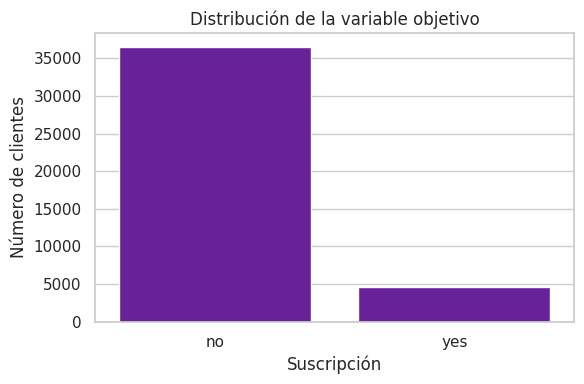

In [44]:
# Calculamos la frecuencia absoluta de cada clase de la variable objetivo.
target_counts = df_eda["y"].value_counts()
# Calculamos el porcentaje de cada clase.
target_pct = df_eda["y"].value_counts(normalize=True).mul(100).round(2)
# Construimos una tabla resumen.
target_table = pd.DataFrame({"frecuencia": target_counts, "porcentaje": target_pct})
# Mostramos la tabla.
display(target_table)

# Creamos la figura.
plt.figure(figsize=(6, 4))
# Representamos el número de clientes por clase.
sns.countplot(data=df_eda, x="y", order=["no", "yes"], color=PALETTE[0])
# Añadimos un título.
plt.title("Distribución de la variable objetivo")
# Etiquetamos el eje horizontal.
plt.xlabel("Suscripción")
# Etiquetamos el eje vertical.
plt.ylabel("Número de clientes")
# Ajustamos los márgenes.
plt.tight_layout()
# Mostramos el gráfico.
plt.show()


## Paso 7. EDA sociodemográfico


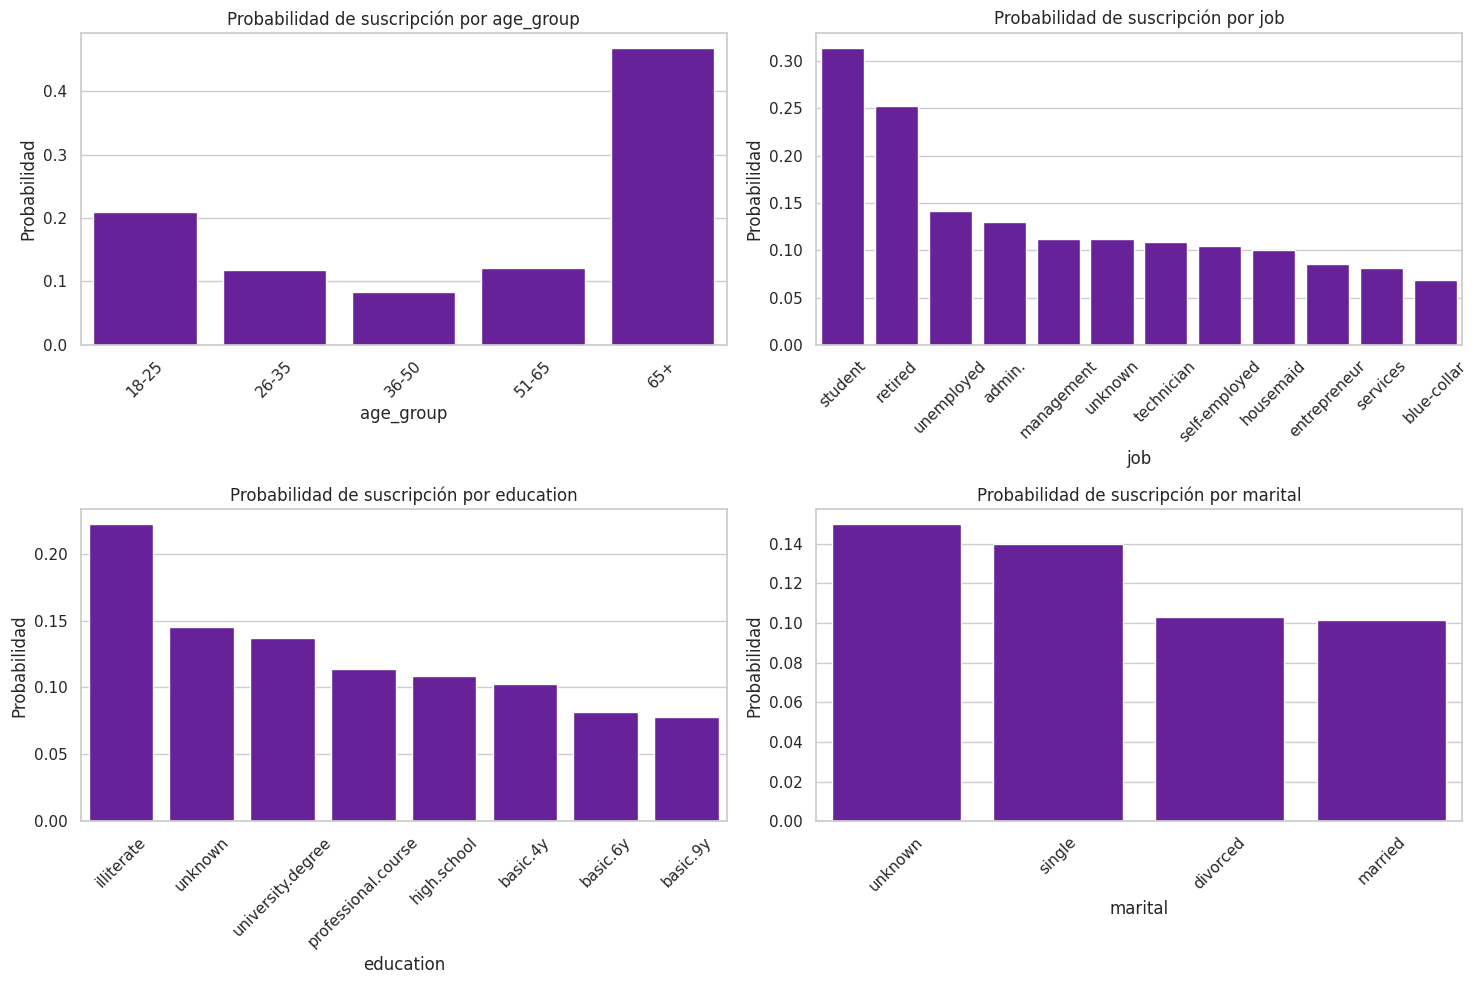

In [45]:
# Definimos las variables sociodemográficas originales.
socio_cols = ["age_group", "job", "education", "marital"]
# Creamos una figura con cuatro paneles.
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
# Convertimos la matriz de ejes en un vector.
axes = axes.flatten()

# Recorremos las variables sociodemográficas.
for i, columna in enumerate(socio_cols):
    # Calculamos la tasa de suscripción para cada categoría.
    data_plot = df_eda.groupby(columna, observed=False)["y_num"].mean().reset_index()
    # Ordenamos de mayor a menor tasa cuando la variable no tiene un orden natural.
    if columna != "age_group":
        # Aplicamos el orden descendente por conversión.
        data_plot = data_plot.sort_values("y_num", ascending=False)
    # Representamos la tasa de suscripción.
    sns.barplot(data=data_plot, x=columna, y="y_num", ax=axes[i], color=PALETTE[0])
    # Añadimos el título.
    axes[i].set_title(f"Probabilidad de suscripción por {columna}")
    # Etiquetamos el eje vertical.
    axes[i].set_ylabel("Probabilidad")
    # Etiquetamos el eje horizontal.
    axes[i].set_xlabel(columna)
    # Rotamos las etiquetas.
    axes[i].tick_params(axis="x", rotation=45)

# Ajustamos la figura.
plt.tight_layout()
# Mostramos los gráficos.
plt.show()


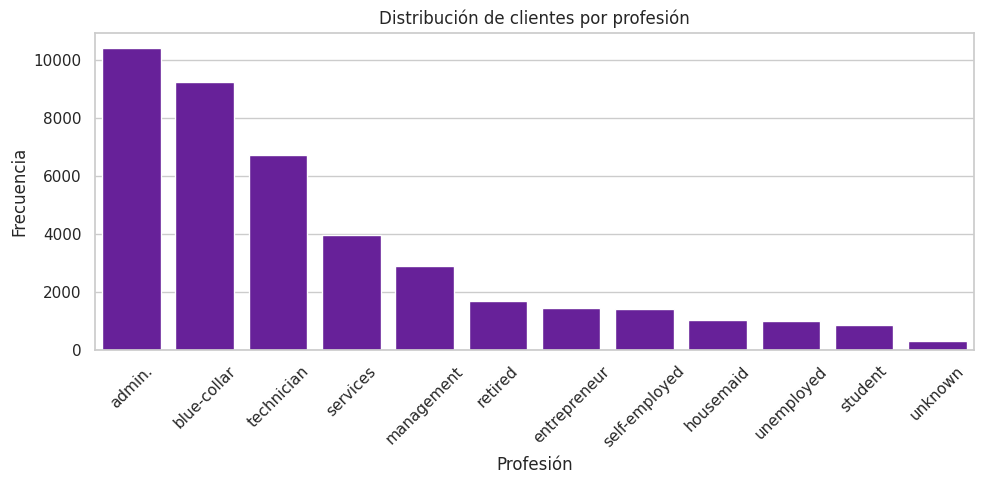

In [46]:
# Creamos una figura para estudiar la distribución de las profesiones.
plt.figure(figsize=(10, 5))
# Representamos el número de clientes de cada profesión.
sns.countplot(data=df_eda, x="job", order=df_eda["job"].value_counts().index, color=PALETTE[0])
# Añadimos el título.
plt.title("Distribución de clientes por profesión")
# Etiquetamos el eje horizontal.
plt.xlabel("Profesión")
# Etiquetamos el eje vertical.
plt.ylabel("Frecuencia")
# Rotamos las etiquetas.
plt.xticks(rotation=45)
# Ajustamos los márgenes.
plt.tight_layout()
# Mostramos el gráfico.
plt.show()


In [47]:
# Recorremos las variables sociodemográficas.
for columna in socio_cols:
    # Calculamos el total de clientes y el número de suscripciones.
    tabla = df_eda.groupby(columna, observed=False)["y_num"].agg(Total="count", Suscritos="sum").reset_index()
    # Calculamos la tasa de conversión.
    tabla["Tasa_conversion"] = tabla["Suscritos"] / tabla["Total"]
    # Ordenamos de mayor a menor conversión.
    tabla = tabla.sort_values("Tasa_conversion", ascending=False)
    # Indicamos qué variable se está mostrando.
    print(f"\nConversión por {columna}")
    # Mostramos la tabla.
    display(tabla)



Conversión por age_group


,age_group,Total,Suscritos,Tasa_conversion
4,65+,619,290,0.468498
0,18-25,1666,349,0.209484
3,51-65,6561,792,0.120713
1,26-35,14847,1740,0.117195
2,36-50,17495,1469,0.083967



Conversión por job


,job,Total,Suscritos,Tasa_conversion
8,student,875,275,0.314286
5,retired,1720,434,0.252326
10,unemployed,1014,144,0.142012
0,admin.,10422,1352,0.129726
4,management,2924,328,0.112175
11,unknown,330,37,0.112121
9,technician,6743,730,0.108260
6,self-employed,1421,149,0.104856
3,housemaid,1060,106,0.100000
2,entrepreneur,1456,124,0.085165



Conversión por education


,education,Total,Suscritos,Tasa_conversion
4,illiterate,18,4,0.222222
7,unknown,1731,251,0.145003
6,university.degree,12168,1670,0.137245
5,professional.course,5243,595,0.113485
3,high.school,9515,1031,0.108355
0,basic.4y,4176,428,0.102490
1,basic.6y,2292,188,0.082024
2,basic.9y,6045,473,0.078246



Conversión por marital


,marital,Total,Suscritos,Tasa_conversion
3,unknown,80,12,0.150000
2,single,11568,1620,0.140041
0,divorced,4612,476,0.103209
1,married,24928,2532,0.101573


## Paso 8. EDA de variables financieras


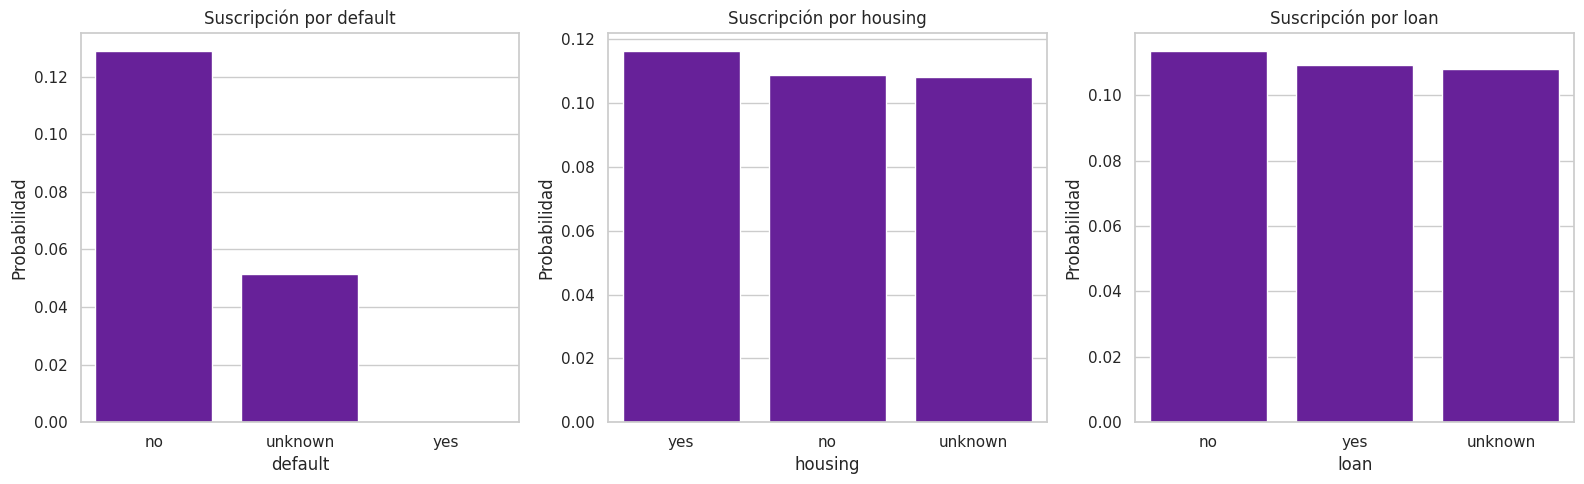

In [48]:
# Definimos las variables financieras originales.
financial_cols = ["default", "housing", "loan"]
# Creamos una figura con tres paneles.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Recorremos las variables financieras.
for i, columna in enumerate(financial_cols):
    # Calculamos la tasa de suscripción por categoría.
    data_plot = df_eda.groupby(columna, observed=False)["y_num"].mean().reset_index()
    # Ordenamos las categorías de mayor a menor conversión.
    data_plot = data_plot.sort_values("y_num", ascending=False)
    # Dibujamos el gráfico.
    sns.barplot(data=data_plot, x=columna, y="y_num", ax=axes[i], color=PALETTE[0])
    # Añadimos el título.
    axes[i].set_title(f"Suscripción por {columna}")
    # Etiquetamos el eje vertical.
    axes[i].set_ylabel("Probabilidad")
    # Etiquetamos el eje horizontal.
    axes[i].set_xlabel(columna)

# Ajustamos la figura.
plt.tight_layout()
# Mostramos los gráficos.
plt.show()


In [49]:
# Recorremos las variables financieras.
for columna in financial_cols:
    # Calculamos total, suscritos y tasa de conversión.
    tabla = df_eda.groupby(columna, observed=False)["y_num"].agg(Total="count", Suscritos="sum").reset_index()
    # Calculamos la tasa de conversión.
    tabla["Tasa_conversion"] = tabla["Suscritos"] / tabla["Total"]
    # Ordenamos la tabla.
    tabla = tabla.sort_values("Tasa_conversion", ascending=False)
    # Indicamos la variable analizada.
    print(f"\nConversión por {columna}")
    # Mostramos la tabla.
    display(tabla)



Conversión por default


,default,Total,Suscritos,Tasa_conversion
0,no,32588,4197,0.12879
1,unknown,8597,443,0.05153
2,yes,3,0,0.00000



Conversión por housing


,housing,Total,Suscritos,Tasa_conversion
2,yes,21576,2507,0.116194
0,no,18622,2026,0.108796
1,unknown,990,107,0.108081



Conversión por loan


,loan,Total,Suscritos,Tasa_conversion
0,no,33950,3850,0.113402
2,yes,6248,683,0.109315
1,unknown,990,107,0.108081


## Paso 9. EDA de campaña y contactos


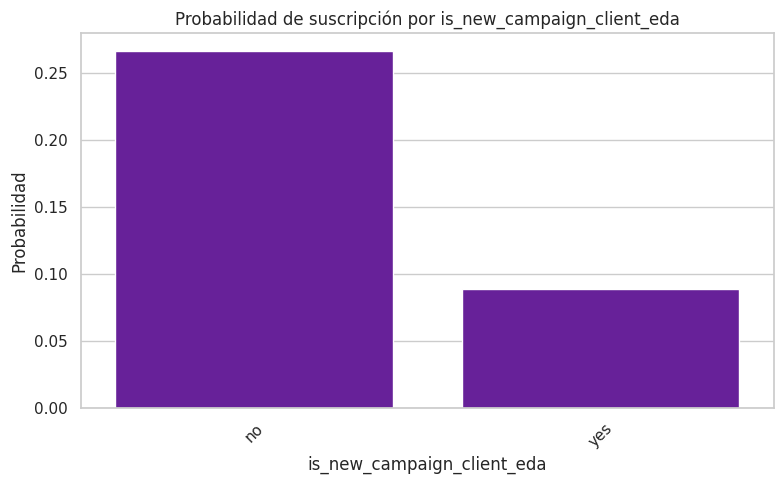

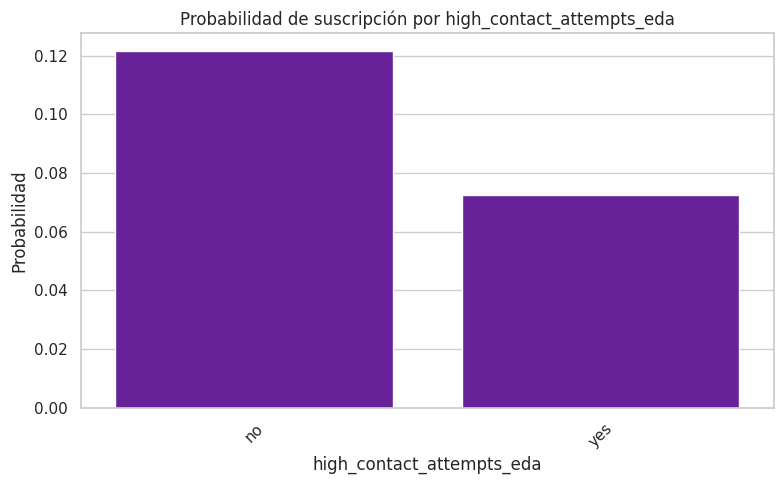

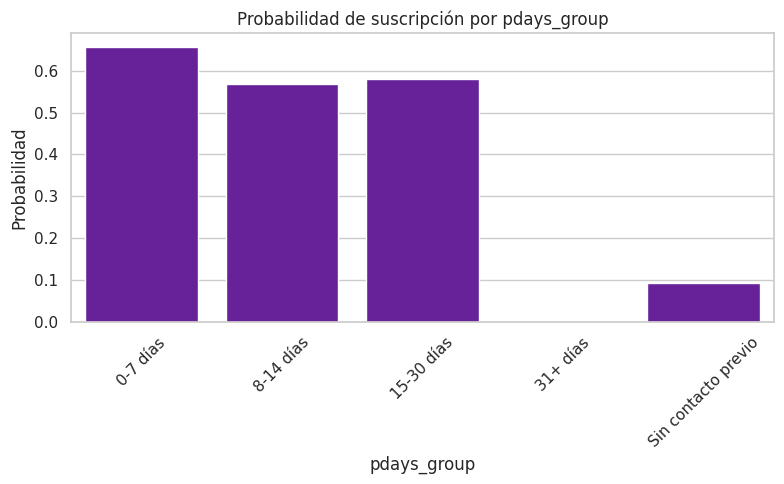

In [50]:
# Definimos los indicadores temporales creados para estudiar la campaña.
campaign_cols = ["is_new_campaign_client_eda", "high_contact_attempts_eda", "pdays_group"]
# Recorremos los indicadores.
for columna in campaign_cols:
    # Calculamos la tasa de suscripción por categoría.
    data_plot = df_eda.groupby(columna, observed=False)["y_num"].mean().reset_index()
    # Ordenamos por tasa de suscripción.
    data_plot = data_plot.sort_values("y_num", ascending=False)
    # Creamos una figura.
    plt.figure(figsize=(8, 5))
    # Dibujamos el gráfico.
    sns.barplot(data=data_plot, x=columna, y="y_num", color=PALETTE[0])
    # Añadimos el título.
    plt.title(f"Probabilidad de suscripción por {columna}")
    # Etiquetamos el eje horizontal.
    plt.xlabel(columna)
    # Etiquetamos el eje vertical.
    plt.ylabel("Probabilidad")
    # Rotamos las etiquetas.
    plt.xticks(rotation=45)
    # Ajustamos los márgenes.
    plt.tight_layout()
    # Mostramos el gráfico.
    plt.show()


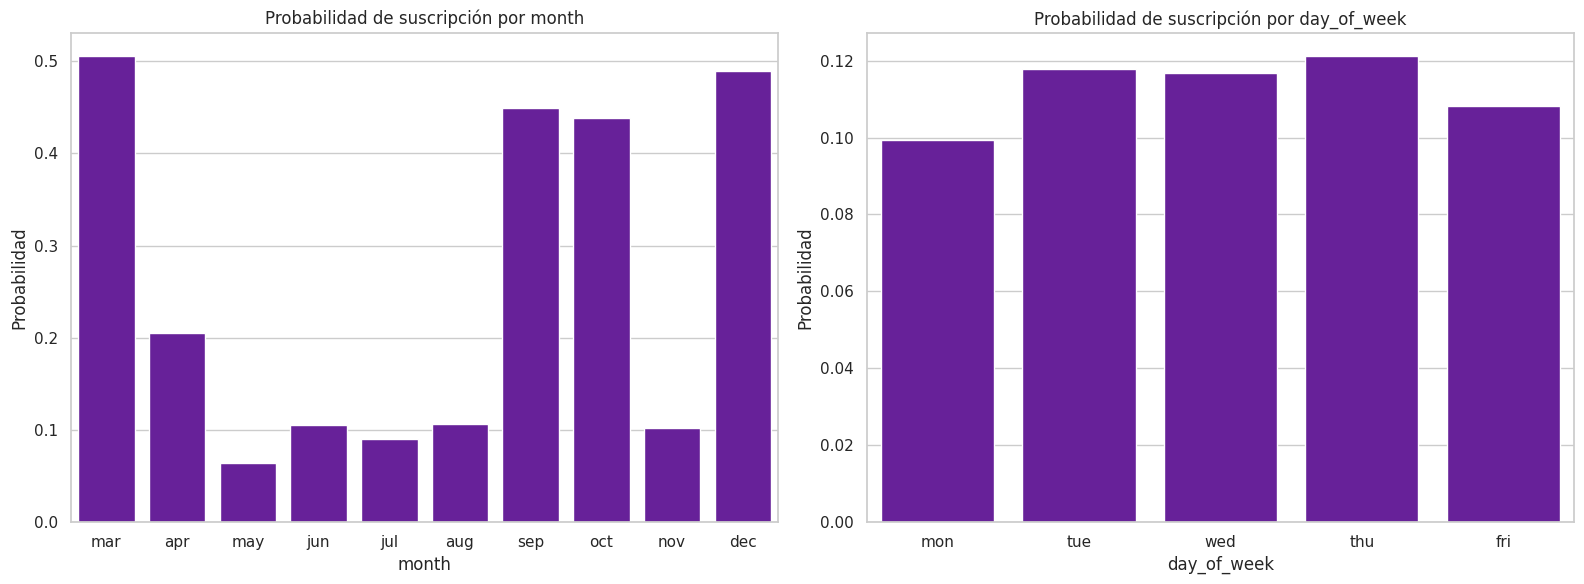

In [51]:
# Definimos las variables temporales de contacto originales.
contact_time_cols = ["month", "day_of_week"]
# Creamos una figura con dos paneles.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Recorremos mes y día.
for i, columna in enumerate(contact_time_cols):
    # Calculamos la tasa de suscripción respetando el orden categórico.
    data_plot = df_eda.groupby(columna, observed=False)["y_num"].mean().reset_index()
    # Representamos la tasa.
    sns.barplot(data=data_plot, x=columna, y="y_num", ax=axes[i], color=PALETTE[0])
    # Añadimos el título.
    axes[i].set_title(f"Probabilidad de suscripción por {columna}")
    # Etiquetamos el eje vertical.
    axes[i].set_ylabel("Probabilidad")
    # Etiquetamos el eje horizontal.
    axes[i].set_xlabel(columna)

# Ajustamos la figura.
plt.tight_layout()
# Mostramos los gráficos.
plt.show()


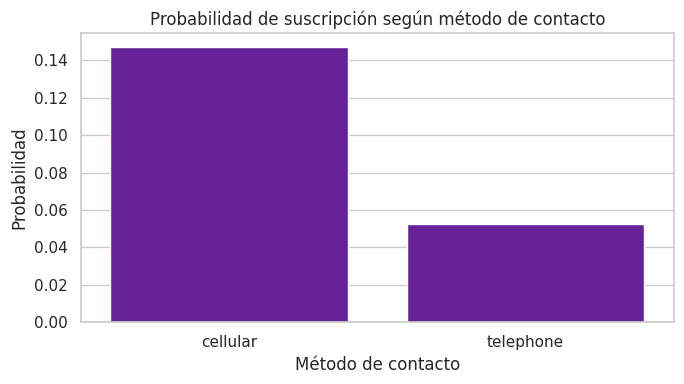

In [52]:
# Calculamos la tasa de suscripción según el método de contacto original.
contact_rate = df_eda.groupby("contact", observed=False)["y_num"].mean().reset_index()
# Creamos una figura.
plt.figure(figsize=(7, 4))
# Representamos la tasa de suscripción.
sns.barplot(data=contact_rate, x="contact", y="y_num", color=PALETTE[0])
# Añadimos el título.
plt.title("Probabilidad de suscripción según método de contacto")
# Etiquetamos el eje horizontal.
plt.xlabel("Método de contacto")
# Etiquetamos el eje vertical.
plt.ylabel("Probabilidad")
# Ajustamos los márgenes.
plt.tight_layout()
# Mostramos el gráfico.
plt.show()


In [53]:
# Calculamos la tasa de suscripción combinando grupo de edad y método de contacto.
age_contact = df_eda.groupby(["age_group", "contact"], observed=False)["y_num"].mean().reset_index(name="subscription_rate")
# Convertimos el resultado a formato matricial.
pivot_age_contact = age_contact.pivot(index="age_group", columns="contact", values="subscription_rate")
# Aplicamos formato porcentual y un gradiente visual.
styled_age_contact = pivot_age_contact.style.format("{:.2%}").background_gradient(cmap="Purples")
# Mostramos la tabla.
display(styled_age_contact)


contact,cellular,telephone
age_group,,
18-25,25.83%,8.37%
26-35,14.86%,5.54%
36-50,11.04%,4.54%
51-65,15.98%,5.27%
65+,48.55%,32.84%


## Paso 10. EDA de duración de llamada


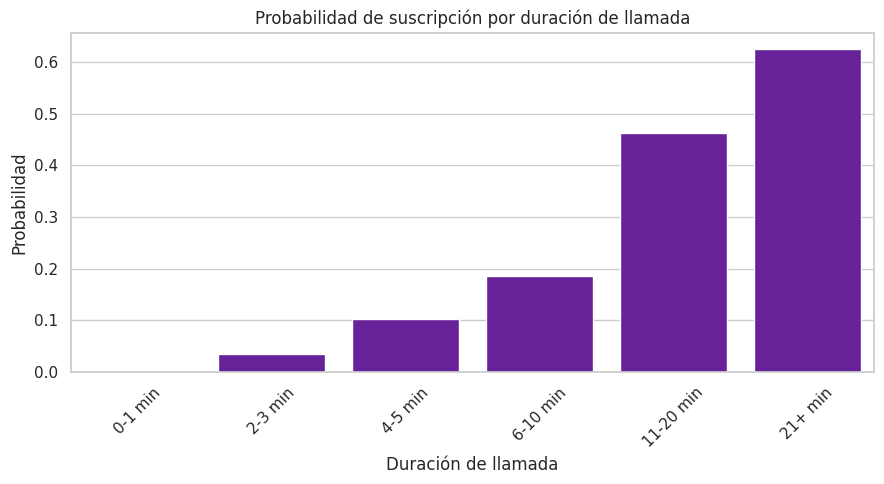

In [54]:
# Calculamos la tasa de suscripción por grupo de duración.
duration_rate = df_eda.groupby("duration_group", observed=False)["y_num"].mean().reset_index()
# Creamos una figura.
plt.figure(figsize=(9, 5))
# Representamos la tasa de suscripción.
sns.barplot(data=duration_rate, x="duration_group", y="y_num", color=PALETTE[0])
# Añadimos el título.
plt.title("Probabilidad de suscripción por duración de llamada")
# Etiquetamos el eje horizontal.
plt.xlabel("Duración de llamada")
# Etiquetamos el eje vertical.
plt.ylabel("Probabilidad")
# Rotamos las etiquetas.
plt.xticks(rotation=45)
# Ajustamos los márgenes.
plt.tight_layout()
# Mostramos el gráfico.
plt.show()


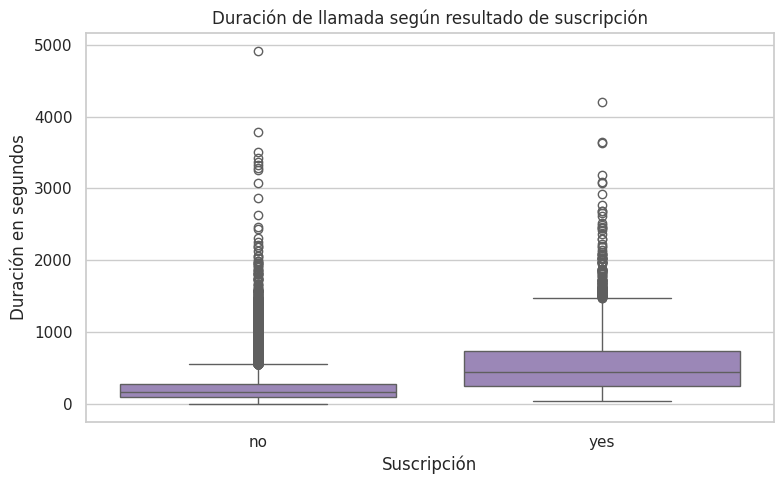

In [55]:
# Creamos una figura para comparar la duración continua entre las dos clases.
plt.figure(figsize=(8, 5))
# Dibujamos un boxplot de duración según la variable objetivo.
sns.boxplot(data=df_eda, x="y", y="duration", color=PALETTE[1])
# Añadimos el título.
plt.title("Duración de llamada según resultado de suscripción")
# Etiquetamos el eje horizontal.
plt.xlabel("Suscripción")
# Etiquetamos el eje vertical.
plt.ylabel("Duración en segundos")
# Ajustamos los márgenes.
plt.tight_layout()
# Mostramos el gráfico.
plt.show()


**Consideración para modelado:** `duration` puede ser muy explicativa en el EDA, pero si el objetivo posterior es predecir la contratación antes de realizar la llamada, su uso como predictor debe revisarse porque la duración completa solo se conoce una vez producido el contacto.


## Paso 11. Análisis de los valores `unknown` de `default`


In [56]:
# Calculamos la frecuencia del indicador de default desconocido.
display(df_eda["default_unknown"].value_counts().sort_index().rename("frecuencia"))
# Calculamos estadísticas de edad según si default es conocido o unknown.
display(df_eda.groupby("default_unknown")["age"].agg(["count", "mean", "median"]))


default_unknown
0    32591
1     8597
Name: frecuencia, dtype: int64

,count,mean,median
default_unknown,,,
0,32591,39.140928,37.0
1,8597,43.371990,43.0


In [57]:
# Definimos las variables categóricas originales que contrastaremos con default_unknown.
chi_cols = ["job", "marital", "education", "housing", "loan", "is_new_campaign_client_eda", "month"]
# Creamos una lista para almacenar los resultados.
results = []

# Recorremos cada variable.
for columna in chi_cols:
    # Construimos la tabla de contingencia.
    contingency_table = pd.crosstab(df_eda["default_unknown"], df_eda[columna])
    # Comprobamos que la tabla permita realizar el contraste.
    if contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1:
        # Ejecutamos la prueba chi-cuadrado.
        chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
        # Interpretamos el resultado al 5 %.
        conclusion = "Asociada" if p_value < 0.05 else "No asociada"
        # Guardamos los resultados.
        results.append({"Variable": columna, "Chi2": chi2, "p_value": p_value, "Conclusion": conclusion})

# Convertimos los resultados a DataFrame.
chi_results = pd.DataFrame(results)
# Ordenamos por p-value.
chi_results = chi_results.sort_values("p_value")
# Mostramos los contrastes.
display(chi_results)


,Variable,Chi2,p_value,Conclusion
0,job,1909.195618,0.000000e+00,Asociada
2,education,2395.932482,0.000000e+00,Asociada
6,month,1040.956383,2.534444e-218,Asociada
1,marital,753.921495,4.257999e-163,Asociada
5,is_new_campaign_client_eda,446.678596,3.810227e-99,Asociada
3,housing,12.606784,1.830087e-03,Asociada
4,loan,3.559963,1.686412e-01,No asociada


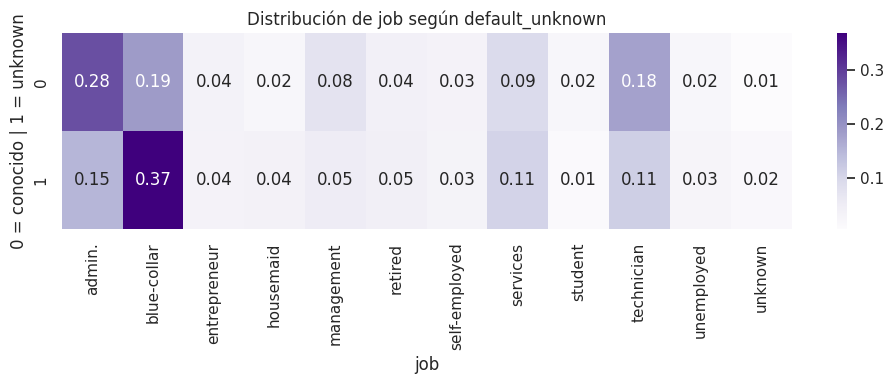

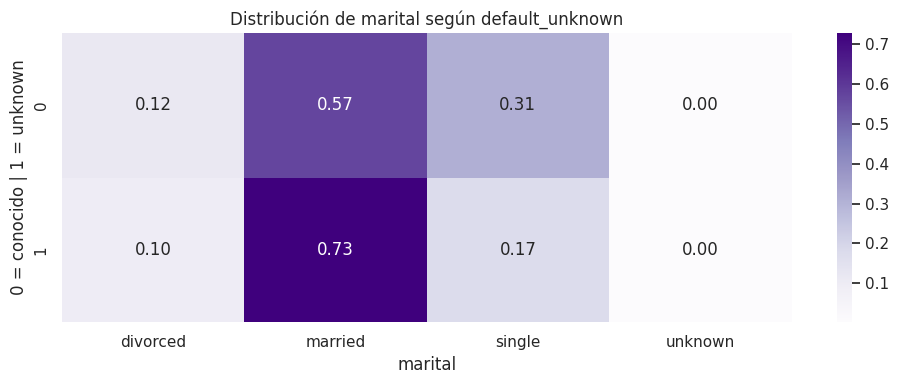

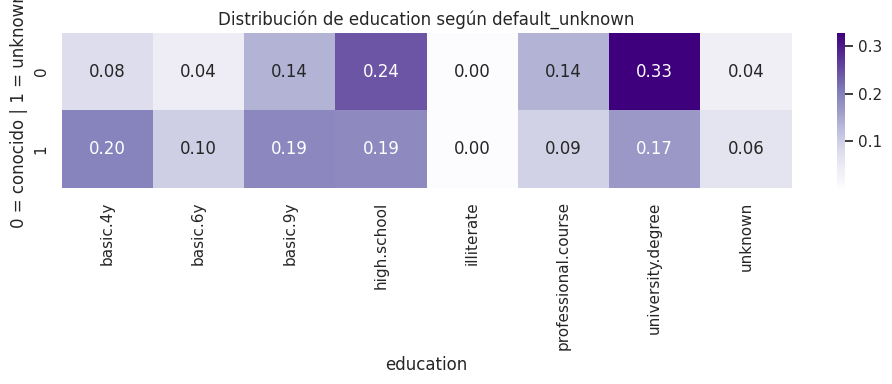

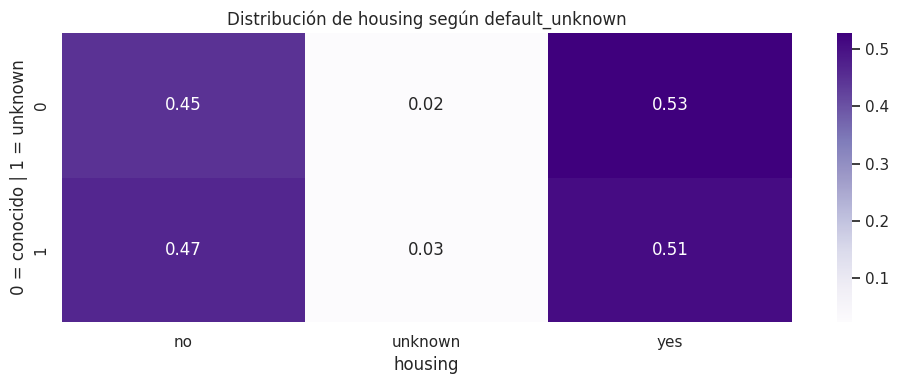

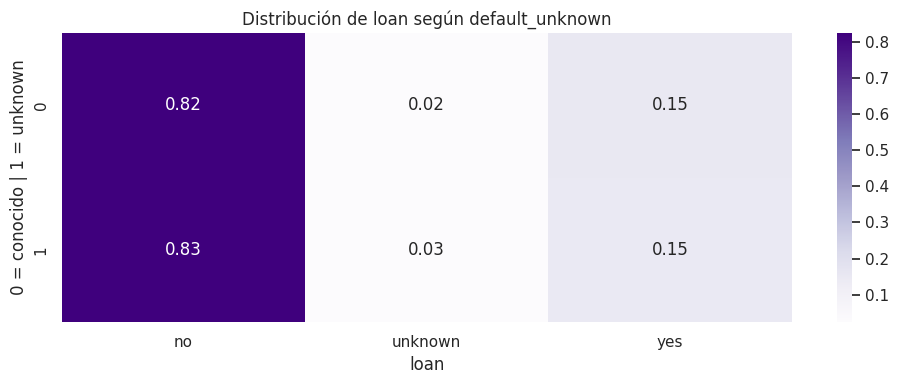

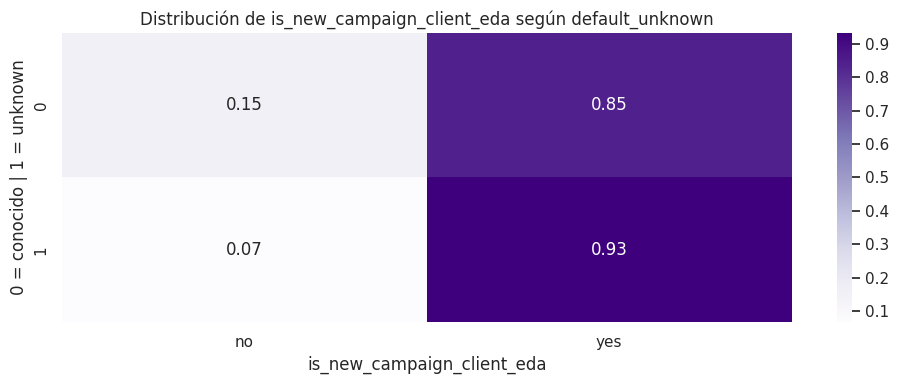

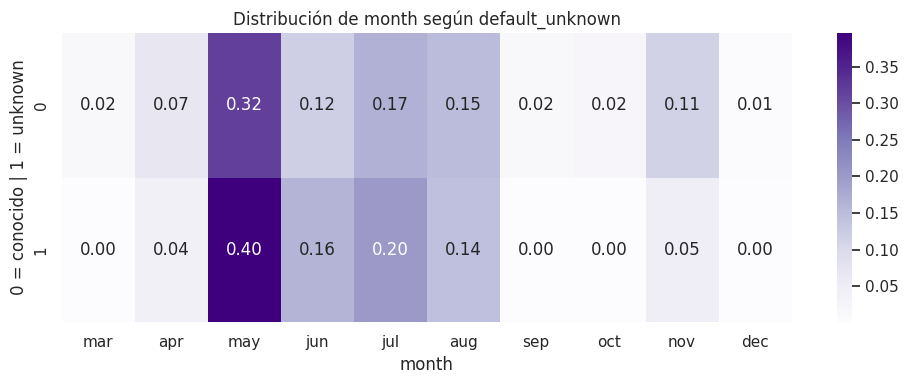

In [58]:
# Recorremos las variables del análisis chi-cuadrado.
for columna in chi_cols:
    # Calculamos las proporciones de cada categoría dentro de cada grupo.
    heatmap_data = pd.crosstab(df_eda["default_unknown"], df_eda[columna], normalize="index")
    # Creamos una figura independiente.
    plt.figure(figsize=(10, 4))
    # Dibujamos el mapa de calor.
    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="Purples")
    # Añadimos el título.
    plt.title(f"Distribución de {columna} según default_unknown")
    # Etiquetamos el eje vertical.
    plt.ylabel("0 = conocido | 1 = unknown")
    # Etiquetamos el eje horizontal.
    plt.xlabel(columna)
    # Ajustamos los márgenes.
    plt.tight_layout()
    # Mostramos el gráfico.
    plt.show()


## Paso 12. EDA de variables macroeconómicas


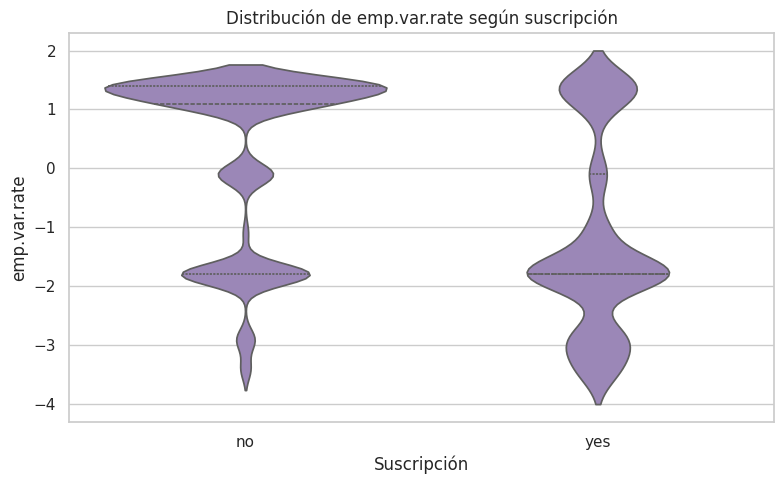

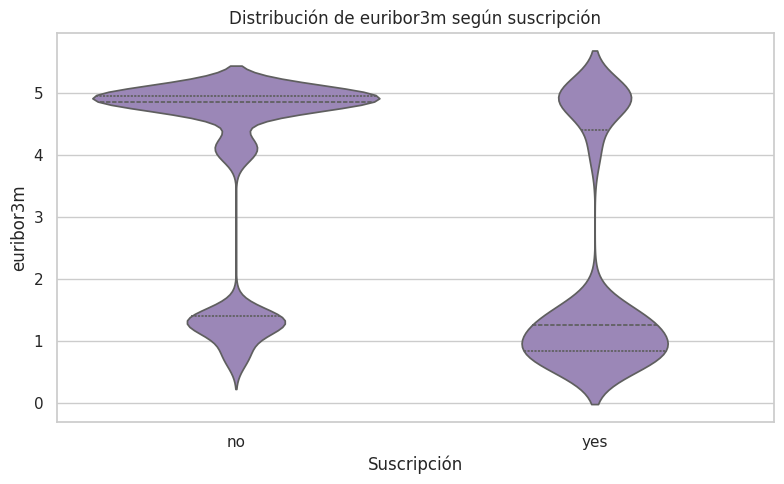

In [59]:
# Definimos las variables macroeconómicas principales del notebook de referencia.
macro_variables = ["emp.var.rate", "euribor3m"]
# Recorremos las variables.
for variable in macro_variables:
    # Creamos una figura.
    plt.figure(figsize=(8, 5))
    # Representamos la distribución según la variable objetivo.
    sns.violinplot(data=df_eda, x="y", y=variable, inner="quartile", color=PALETTE[1])
    # Añadimos el título.
    plt.title(f"Distribución de {variable} según suscripción")
    # Etiquetamos el eje horizontal.
    plt.xlabel("Suscripción")
    # Etiquetamos el eje vertical.
    plt.ylabel(variable)
    # Ajustamos los márgenes.
    plt.tight_layout()
    # Mostramos el gráfico.
    plt.show()


In [60]:
# Definimos todas las variables macroeconómicas originales.
macro_all = ["emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]
# Calculamos la media de cada variable según el resultado de suscripción.
macro_summary = df_eda.groupby("y")[macro_all].mean().T
# Mostramos la comparación.
display(macro_summary)


y,no,yes
emp.var.rate,0.248875,-1.233448
cons.price.idx,93.603757,93.354386
cons.conf.idx,-40.593097,-39.789784
euribor3m,3.811491,2.123135
nr.employed,5176.166600,5095.115991


## Paso 13. Correlaciones numéricas antes de la limpieza


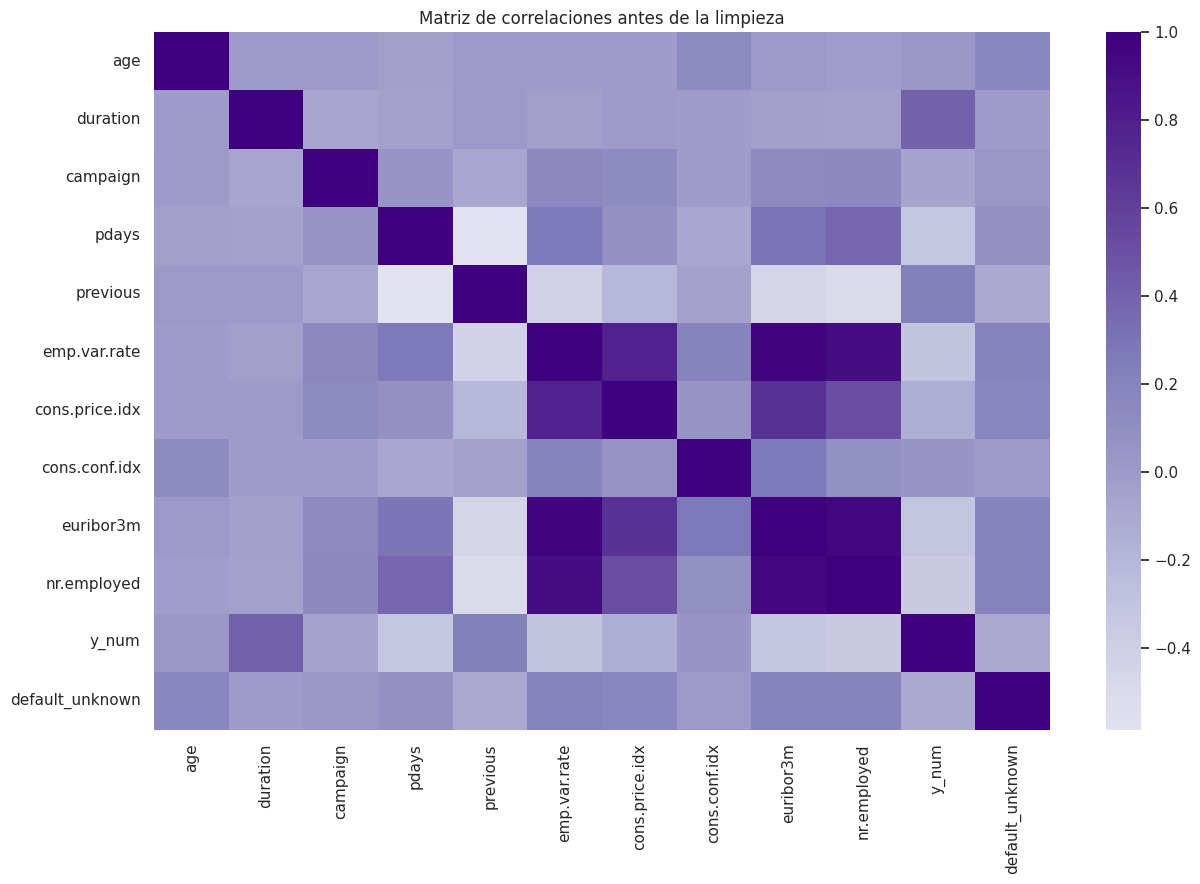

In [61]:
# Seleccionamos las variables numéricas del DataFrame de EDA.
numeric_df = df_eda.select_dtypes(include=np.number)
# Calculamos la matriz de correlaciones.
correlation_matrix = numeric_df.corr()
# Creamos una figura amplia.
plt.figure(figsize=(13, 9))
# Dibujamos el mapa de calor.
sns.heatmap(correlation_matrix, cmap="Purples", center=0, annot=False)
# Añadimos un título.
plt.title("Matriz de correlaciones antes de la limpieza")
# Ajustamos los márgenes.
plt.tight_layout()
# Mostramos el gráfico.
plt.show()


In [62]:
# Extraemos las correlaciones con la variable objetivo numérica temporal.
target_correlations = correlation_matrix["y_num"].drop("y_num")
# Ordenamos las correlaciones por su magnitud absoluta.
target_correlations = target_correlations.reindex(target_correlations.abs().sort_values(ascending=False).index)
# Mostramos las correlaciones ordenadas.
display(target_correlations.to_frame("correlacion_con_y"))


,correlacion_con_y
duration,0.405274
nr.employed,-0.354678
pdays,-0.324914
euribor3m,-0.307771
emp.var.rate,-0.298334
previous,0.230181
cons.price.idx,-0.136211
default_unknown,-0.099293
campaign,-0.066357
cons.conf.idx,0.054878


## Paso 14. Conclusiones del EDA que motivan la limpieza

A partir de la exploración anterior, la función `limpieza_fintech()` formaliza las transformaciones del dataset:

- Renombra las columnas para mejorar su interpretación.
- Conserva como información explícita los `unknown` de `job`, `marital`, `education` y `default`, renombrándolos como `undisclosed`.
- Elimina registros con `unknown` en `housing` o `loan`.
- Elimina duplicados utilizando las variables predictoras y excluyendo la variable objetivo del criterio.
- Agrupa la duración de llamada.
- Ordena cronológicamente mes y día.
- Crea indicadores de cliente nuevo y de alta intensidad de contactos.
- Reubica la variable objetivo al final.

La limpieza se ejecuta **a partir del dataset RAW original**, no sobre `df_eda`, para evitar que las variables auxiliares creadas exclusivamente para el análisis se incorporen accidentalmente al dataset limpio.


## Paso 15. Aplicación de `limpieza_fintech()` después del EDA


In [63]:
# Guardamos las dimensiones del dataset RAW antes de limpiar.
shape_before = df_fintech.shape
# Aplicamos la función de limpieza sobre el dataset RAW original.
df_fintech_clean = limpieza_fintech(df_fintech)
# Guardamos las dimensiones del dataset después de limpiar.
shape_after = df_fintech_clean.shape
# Mostramos las dimensiones anteriores.
print(f"Antes de limpiar: {shape_before[0]:,} filas x {shape_before[1]} columnas")
# Mostramos las dimensiones posteriores.
print(f"Después de limpiar: {shape_after[0]:,} filas x {shape_after[1]} columnas")
# Mostramos el número de filas eliminadas.
print(f"Filas eliminadas: {shape_before[0] - shape_after[0]:,}")
# Mostramos una muestra del dataset limpio.
display(df_fintech_clean.head())


Antes de limpiar: 41,188 filas x 21 columnas
Después de limpiar: 40,186 filas x 24 columnas
Filas eliminadas: 1,002


,age,job_type,marital_status,education_level,credit_default,has_housing_loan,has_personal_loan,contact_method,contact_month,contact_day,call_duration,contact_attempts,previously_contacted,previous_contacts,previous_campaign_outcome,employment_variation_rate,consumer_price_index,consumer_confidence_index,euribor_3m_rate,total_employment,call_duration_group,is_new_campaign_client,high_contact_attempts,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,4-5 min,yes,no,no
1,57,services,married,high.school,undisclosed,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,2-3 min,yes,no,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,4-5 min,yes,no,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,2-3 min,yes,no,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,6-10 min,yes,no,no


## Paso 16. Validación del dataset limpio


¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 40,186 filas y 24 columnas.
##########################################################################################
¿Cuáles son las primeras cinco filas del conjunto de datos?


,age,job_type,marital_status,education_level,credit_default,has_housing_loan,has_personal_loan,contact_method,contact_month,contact_day,call_duration,contact_attempts,previously_contacted,previous_contacts,previous_campaign_outcome,employment_variation_rate,consumer_price_index,consumer_confidence_index,euribor_3m_rate,total_employment,call_duration_group,is_new_campaign_client,high_contact_attempts,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,4-5 min,yes,no,no
1,57,services,married,high.school,undisclosed,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,2-3 min,yes,no,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,4-5 min,yes,no,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,2-3 min,yes,no,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,6-10 min,yes,no,no


----------------------------------------------------------------------------------------------------
¿Cuáles son las últimas cinco filas del conjunto de datos?


,age,job_type,marital_status,education_level,credit_default,has_housing_loan,has_personal_loan,contact_method,contact_month,contact_day,call_duration,contact_attempts,previously_contacted,previous_contacts,previous_campaign_outcome,employment_variation_rate,consumer_price_index,consumer_confidence_index,euribor_3m_rate,total_employment,call_duration_group,is_new_campaign_client,high_contact_attempts,subscribed
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,6-10 min,yes,no,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,6-10 min,yes,no,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,4-5 min,yes,no,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,6-10 min,yes,no,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,239,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,4-5 min,no,no,no


----------------------------------------------------------------------------------------------------
¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


...

----------------------------------------------------------------------------------------------------
¿Cuántos valores nulos hay en cada columna del DataFrame?


age                          0
job_type                     0
marital_status               0
education_level              0
credit_default               0
has_housing_loan             0
has_personal_loan            0
contact_method               0
contact_month                0
contact_day                  0
call_duration                0
contact_attempts             0
previously_contacted         0
previous_contacts            0
previous_campaign_outcome    0
employment_variation_rate    0
consumer_price_index         0
consumer_confidence_index    0
euribor_3m_rate              0
total_employment             0
call_duration_group          0
is_new_campaign_client       0
high_contact_attempts        0
subscribed                   0
dtype: int64

----------------------------------------------------------------------------------------------------
¿Cuál es el porcentaje de valores nulos por columna, ordenado de mayor a menor?


,Col,pct
0,age,0.0
1,job_type,0.0
2,marital_status,0.0
3,education_level,0.0
4,credit_default,0.0
5,has_housing_loan,0.0
6,has_personal_loan,0.0
7,contact_method,0.0
8,contact_month,0.0
9,contact_day,0.0


----------------------------------------------------------------------------------------------------
## Valores nulos: Visualización


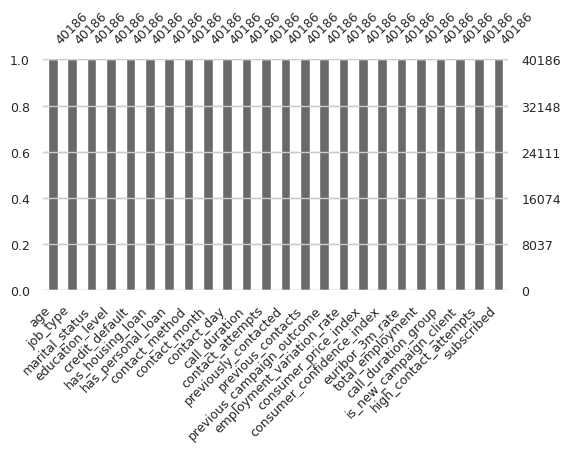

----------------------------------------------------------------------------------------------------
## Visualización de patrones en valores nulos


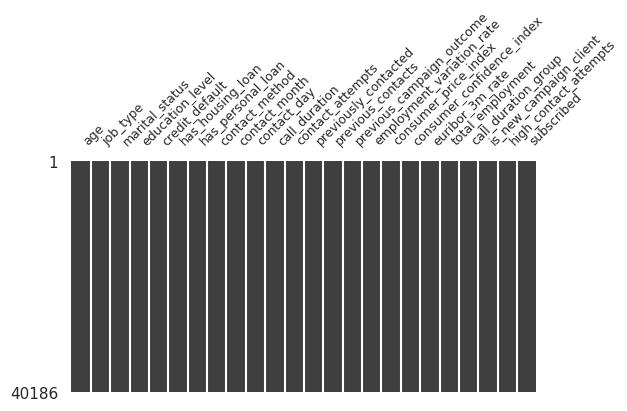

----------------------------------------------------------------------------------------------------
##Número de filas duplicadas (considerando todas las columnas)
	Hay 0 filas duplicadas.


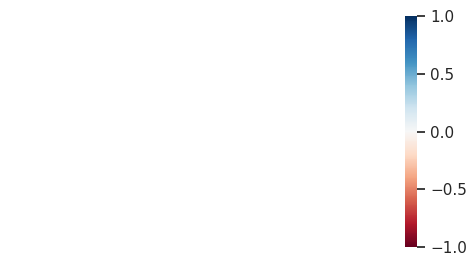

----------------------------------------------------------------------------------------------------
##########################################################################################


0                           age
1                      job_type
2                marital_status
3               education_level
4                credit_default
5              has_housing_loan
6             has_personal_loan
7                contact_method
8                 contact_month
9                   contact_day
10                call_duration
11             contact_attempts
12         previously_contacted
13            previous_contacts
14    previous_campaign_outcome
15    employment_variation_rate
16         consumer_price_index
17    consumer_confidence_index
18              euribor_3m_rate
19             total_employment
20          call_duration_group
21       is_new_campaign_client
22        high_contact_attempts
23                   subscribed
Name: columnas_finales, dtype: object

Duplicados exactos finales: 0


Series([], Name: nulos, dtype: int64)

Valores finales de has_housing_loan: ['no' 'yes']
Valores finales de has_personal_loan: ['no' 'yes']
Valores finales de credit_default: ['no' 'undisclosed' 'yes']


In [64]:
# Ejecutamos la exploración simple de la función propia sobre el resultado limpio.
exploracion_inicial(df_fintech_clean)

# Mostramos los nombres finales de las columnas.
display(pd.Series(df_fintech_clean.columns, name="columnas_finales"))

# Comprobamos que la variable objetivo haya sido renombrada correctamente.
assert "subscribed" in df_fintech_clean.columns, "La limpieza no ha creado la columna subscribed."
# Comprobamos que la columna RAW y ya no permanezca en el resultado.
assert "y" not in df_fintech_clean.columns, "La columna y original sigue presente después de la limpieza."

# Calculamos los duplicados exactos restantes.
print(f"Duplicados exactos finales: {df_fintech_clean.duplicated().sum():,}")

# Calculamos los nulos finales.
final_nulls = df_fintech_clean.isna().sum().sort_values(ascending=False)
# Mostramos únicamente las columnas con nulos.
display(final_nulls[final_nulls > 0].rename("nulos"))

# Comprobamos que housing ya no contenga unknown.
print("Valores finales de has_housing_loan:", df_fintech_clean["has_housing_loan"].unique())
# Comprobamos que loan ya no contenga unknown.
print("Valores finales de has_personal_loan:", df_fintech_clean["has_personal_loan"].unique())
# Comprobamos los valores finales de credit_default.
print("Valores finales de credit_default:", df_fintech_clean["credit_default"].unique())


## Paso 17. Comparación de la variable objetivo antes y después de limpiar


In [65]:
# Calculamos la tasa de suscripción antes de la limpieza.
conversion_before = (df_fintech["y"] == "yes").mean()
# Calculamos la tasa de suscripción después de la limpieza.
conversion_after = (df_fintech_clean["subscribed"] == "yes").mean()
# Construimos una tabla comparativa.
conversion_comparison = pd.DataFrame(
    {
        "momento": ["Antes de limpiar", "Después de limpiar"],
        "tasa_suscripcion": [conversion_before, conversion_after]
    }
)
# Mostramos la tabla con formato porcentual.
display(conversion_comparison.style.format({"tasa_suscripcion": "{:.2%}"}))


,momento,tasa_suscripcion
0,Antes de limpiar,11.27%
1,Después de limpiar,11.28%


## Paso 18. Exportación del dataset limpio


In [66]:
# Nos aseguramos de que la carpeta de salida exista.
DATA_DIR.mkdir(parents=True, exist_ok=True)
# Guardamos el dataset limpio en formato CSV sin incluir el índice de pandas.
df_fintech_clean.to_csv(OUTPUT_FILE, index=False)
# Mostramos la ruta exacta del fichero generado.
print(f"Dataset limpio guardado en: {OUTPUT_FILE}")


Dataset limpio guardado en: /home/diego/Escritorio/Fintech_TFM/00_data/01_processed/df_fintech_final.csv


## Paso 19. Comprobación final de la exportación


In [67]:
# Volvemos a leer el fichero exportado.
df_export_check = pd.read_csv(OUTPUT_FILE)
# Mostramos las dimensiones recuperadas desde disco.
print(f"Dimensiones del CSV exportado: {df_export_check.shape[0]:,} filas x {df_export_check.shape[1]} columnas")
# Comprobamos que coincidan con el DataFrame limpio.
assert df_export_check.shape == df_fintech_clean.shape, "Las dimensiones del fichero exportado no coinciden."
# Confirmamos que la exportación ha terminado correctamente.
print("Exportación comprobada correctamente.")


Dimensiones del CSV exportado: 40,186 filas x 24 columnas
Exportación comprobada correctamente.
